In [82]:
from xaikd import datasets, models, utils, constants, attributors

from torch.utils.data import random_split, DataLoader

from torchvision.datasets import CIFAR100, ImageNet
from torchmetrics.classification import BinaryAUROC

from torch.nn import functional as F

import pandas as pd
import torch
import numpy as np 
import numpy.typing as npt

from tqdm.notebook import tqdm
from torch import nn
import matplotlib as mpl
from matplotlib import pyplot as plt

from glob import glob

In [2]:
DEVICE = utils.get_device()

DEVICE

DATA_SIZE = 0.01


SELECTED_GROUP = "butterfly"

In [3]:
dataset = datasets.construct("imagenet")

In [4]:
def get_fine_labels(name):

    return datasets.imagenet.IMAGENET_SUPERCLASS_MAPPING[name]
    # if "class" in name:
    #     label = int(name.replace("class", ""))
    #     return [label]
    # df = pd.read_csv(constants.CIFAR100_SUPER_CLASS_MAPPING)
    # return sorted(df[df.coarse_label_name == name].fine_label.values)
SELECTED_CLASSES = get_fine_labels(SELECTED_GROUP)
SELECTED_CLASSES

[321, 322, 323, 324, 325, 326]

In [5]:
NOT_SELECTED_CLASSES = sorted(set(np.arange(1000)).difference(SELECTED_CLASSES))

In [6]:
NOT_SELECTED_CLASSES

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


In [7]:
def target_transform(label):
    if label in SELECTED_CLASSES:
        return 1
    else:
        return 0

In [8]:
trng = torch.Generator()
trng.manual_seed(1)

transform = datasets.construct("imagenet").input_transformation
ds_train = ImageNet(root="../../datasets/imagenet", split="train", transform=transform, target_transform=target_transform)
ds_train, _ = random_split(ds_train, [DATA_SIZE, 1-DATA_SIZE])

ds_val = ImageNet(root="../../datasets/imagenet", split="val", transform=transform, target_transform=target_transform)

dl_train = DataLoader(ds_train, num_workers=12, shuffle=False, batch_size=128)
dl_val = DataLoader(ds_val, num_workers=12, shuffle=False,  batch_size=128)

In [19]:
def extract_logits(model, dl, verbose=False):
    arr_logits = []
    arr_ys = []
    for x, y in tqdm(dl, disable=not verbose, desc="Extract Logits"):
        x = x.to(DEVICE)
        logits = model(x).detach().cpu().numpy()
        arr_logits.extend(logits.tolist())
        arr_ys.extend(y.tolist())

    return np.array(arr_logits), np.array(arr_ys)
    
ARR_LOGITS, ARR_YS  = extract_logits(model, dl_train)

In [37]:
ARR_LOGITS

array([-18.83021355,  -8.79203892, -13.73727608, ..., -11.93183136,
       -20.17228889, -12.41753006])

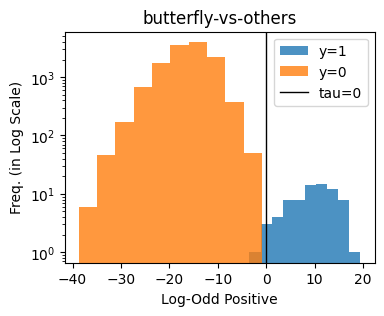

In [29]:
def ano():

    vmin = np.min(ARR_LOGITS)
    vmax = np.max(ARR_LOGITS)
    
    bins = np.linspace(vmin, vmax, 100)
    
    plt.figure(figsize=(4, 3))
    plt.title(f"{SELECTED_GROUP}-vs-others")
    for y in [1, 0]:
        plt.hist(ARR_LOGITS[ARR_YS==y], label=f"y={y}", alpha=0.8)
    plt.yscale("log")
    plt.ylabel("Freq. (in Log Scale)")
    plt.xlabel("Log-Odd Positive")
    plt.axvline(0, ls="-", lw=1, color="k", label="tau=0")
    plt.legend()
ano()

In [9]:
def ano():
    for label, dl in [
        ("train", dl_train),
        ("val", dl_val),
    ]:
        arr_values = []
        for _, y in tqdm(dl):
            arr_values.extend(y.tolist())
        print(f"[subset={label}] p(y=1)={np.mean(arr_values):.4f}")
ano()

  0%|          | 0/101 [00:00<?, ?it/s]

[subset=train] p(y=1)=0.0058


  0%|          | 0/391 [00:00<?, ?it/s]

[subset=val] p(y=1)=0.0060


In [30]:
class LastLayerBinary(nn.Module):
    def __init__(self, fc):
        super().__init__()
        self.fc = fc

    def forward(self, x):
        logits = self.fc(x)
        lse_pos = torch.logsumexp(logits[:, SELECTED_CLASSES], dim=1)
        lse_neg = torch.logsumexp(logits[:, NOT_SELECTED_CLASSES], dim=1)
        return lse_pos - lse_neg
        
    
def construct_model():
    model = models.get_trained_model("imagenet-resnet18-tv")

    model.fc = LastLayerBinary(model.fc)
    model.eval()
    model.to(DEVICE)
    
    return model

def sanity_check():
    
    model  = construct_model()

    output = model(torch.randn((5, 3, 224, 224)).to(DEVICE))
    assert output.shape == (5,)
    print("[Sanity check passed]: Model is callable")
    
sanity_check()

[Sanity check passed]: Model is callable


In [31]:
model = construct_model()
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [32]:
def compute_performance(model, verbose=False):
    dl =  dl_val
    metric = BinaryAUROC(thresholds=20)
    model.to(DEVICE)

    for x, y in tqdm(dl, disable=not verbose):
        x = x.to(DEVICE)
        logit = model(x).cpu()
        
        metric.update(logit, y)

    metric = float(metric.compute())
    metric = np.max([metric, 1-metric])
    return metric
    
ref_performance = compute_performance(model, verbose=True)    
ref_performance

  0%|          | 0/391 [00:00<?, ?it/s]

0.9933035969734192

# Extract Activation

In [33]:
class OutputQuantity:
    def __call__(self, logits, target_logits):
        raise NotImplementedError()
    def __str__(self):
        return self.__class__.__name__


class LogOddWinningClass(OutputQuantity):
    def __call__(self, logits, targets):
        return torch.sign(logits).detach() * logits

## Selection Criteria

In [38]:
class CriteriaSampleSelection:
    def __call__(self, logits: torch.Tensor):
        raise NotImplementedError("error")
    def slug(self) -> str:
        raise NotImplementedError("error")

class CriteriaSelectNSamples(CriteriaSampleSelection):
    
    def __init__(self, N: int, threshold=0, verbose=False):
        self.N = N
        
        arr_logits = ARR_LOGITS
        self.total = arr_logits.shape[0]
        
        is_in_left_region = arr_logits < threshold
        is_in_right_region = arr_logits >= threshold


        self.criteria_left = np.sort(arr_logits[is_in_left_region])[-N]
        self.criteria_right = np.sort(arr_logits[is_in_right_region])[N]
        

    def __call__(self, logits):
        return (logits > self.criteria_left) * (logits <= self.criteria_right)
        
    def __str__(self):
        return f"SelectNSamples(N={self.N}, total={self.total}, [{self.criteria_left:.2f}, {self.criteria_right:.2f}])"
    def slug(self):
        return f"select-{self.N}"

class CriteriaSelectNSamplesOppositeSide(CriteriaSampleSelection):
    
    def __init__(self, N: int, threshold=0, verbose=False):
        self.N = N
        
        arr_logits = ARR_LOGITS
        self.total = arr_logits.shape[0]
        
        is_in_left_region = arr_logits < threshold
        is_in_right_region = arr_logits >= threshold


        self.criteria_left = np.sort(arr_logits[is_in_left_region])[N]
        self.criteria_right = np.sort(arr_logits[is_in_right_region])[-N]
        

    def __call__(self, logits):
        return torch.logical_or(
            (logits < self.criteria_left),
            (logits >= self.criteria_right)
        )
        
    def __str__(self):
        return f"SelectNSamplesOppositeSide(N={self.N}, total={self.total}, [{self.criteria_left:.2f}, {self.criteria_right:.2f}])"
    def slug(self):
        return f"select-opposite-side-{self.N}"
        
class CriteriaSelectAllSamples(CriteriaSampleSelection):
    def __call__(self, logits):
        return torch.ones_like(logits).int().to(logits.device)
        
    def __str__(self):
        return f"SelectNSamples(N=∞)"

    def slug(self):
        return f"select-all"
    
def ano():
    arr_logits = torch.from_numpy(ARR_LOGITS)
    
    for N in [5, 10, 50]:
        
        criteria = CriteriaSelectNSamples(N=N)
    
        np.testing.assert_allclose(
            criteria(arr_logits).sum(),
            2*N
        )
        print(f"sanity check: {criteria} passed!")

    all_cri = CriteriaSelectAllSamples()
    all_cri(arr_logits)
    print(f"sanity check: {all_cri} passed!")

    print(f"sanity check: {CriteriaSelectNSamplesOppositeSide(N=10)(arr_logits)} passed!")
ano()

sanity check: SelectNSamples(N=5, total=12812, [-1.01, 3.59]) passed!
sanity check: SelectNSamples(N=10, total=12812, [-1.90, 5.19]) passed!
sanity check: SelectNSamples(N=50, total=12812, [-4.46, 12.68]) passed!
sanity check: SelectNSamples(N=∞) passed!
sanity check: tensor([False, False, False,  ..., False, False, False]) passed!


## Estimation

In [48]:

def extract_activation_context_for_task(
    model: nn.Module,
    layer: str,
    sample_selection_criteria: CriteriaSampleSelection,
    data_loader=dl_train,    
    seed=1,
    device=DEVICE,
    number_of_selected_spatial_locations=20,
    strict_mode=False,
    verbose=False
):

    arr_logodds = []
    arr_act = []
    arr_ctx = []

    rng = np.random.default_rng(seed=1)

    output_quantity = LogOddWinningClass()

    try:
        
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

        
        for batch in tqdm(data_loader, desc=f"[layer={layer}] extract act ctx (wrt {output_quantity}, criteria={sample_selection_criteria})"):
            x, y = batch
            x = x.to(device)


            logits = model(x)
            
            arr_logodds = output_quantity(logits, y)
            
            (arr_logodds).sum().backward()
            act = utils.interceptor.get_output(module)

            assert act.grad is not None
            ctx = act.grad
            
            output_dimensions = act.shape[1:]

            assert ctx.shape == act.shape

            act = act.detach().cpu().numpy()
            ctx = ctx.detach().cpu().numpy()

            
            selected = sample_selection_criteria(arr_logodds).detach().cpu().numpy()
            if selected.sum() == 0:
                continue

            act = act[selected,:, :, :]
            ctx = ctx[selected,:, :, :]
            
            selected_act, selected_ctx = utils.subsample_tensors(
                act,
                ctx,
                num_locations=number_of_selected_spatial_locations,
                rng=rng,
            )
            

            arr_act.append(selected_act)
            arr_ctx.append(selected_ctx)

    finally:
        hook.remove()
        model.fc.task_id = None

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)
 
    return arr_act, arr_ctx

def ano():

    arr_act, arr_ctx = extract_activation_context_for_task(
        model, 
        "layer3",
        sample_selection_criteria=CriteriaSelectAllSamples(),
        # sample_selection_criteria=CriteriaSelectNSamples(N=50)    

    )
    print(f"arr_act.shape={arr_act.shape}")
    PCA(arr_act, arr_ctx)

    print(f"Sanity check: passed!")
ano()

[layer=layer3] extract act ctx (wrt LogOddWinningClass, criteria=SelectNSamples(N=∞)):   0%|          | 0/101 …

layer3: output-dims=torch.Size([256, 14, 14])
arr_act.shape=(256240, 256)
Sanity check: passed!


# Construct Basis

In [49]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs, sort_func(eigvals)


class BasisInterface:
    def get_Uk(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

class PCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        N, d = arr_act.shape
        cov = arr_act.T @ arr_act / N
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class GradPCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        N, d = arr_act.shape

        cov = arr_ctx.T @ arr_ctx / N
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]
        
class PRCASortAbs(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        N, d = arr_act.shape

        cov = (arr_act.T @ arr_ctx + arr_ctx.T @ arr_act) / N
        self.U, self.eigvals = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCAPosDef(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / ( np.sum(pca.eigvals) ** 0.5)
        arr_ctx = arr_ctx / ( np.sum(gradpca.eigvals) ** 0.5)


        cov_a = 2*(arr_act.T @ arr_act)
        cov_c = 2*(arr_ctx.T @ arr_ctx)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        
        cov = cov_ac + cov_a + cov_c
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


# Estimate Performance

In [54]:
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            (Uk@Uk.T).unsqueeze(2).unsqueeze(3)
        )
    return fh

def compute_task_aurocs_at_k(
    model, layer, 
    arr_ks,
    sample_selection_criteria,
    arr_basis_names=[
        PCA
    ],
    
):
    arr_act, arr_ctx = extract_activation_context_for_task(
        model=model, 
        layer=layer, 
        sample_selection_criteria=sample_selection_criteria
    )
    
    module = getattr(model, layer)

    arr_dfs = []
    for basis_class in arr_basis_names:
        arr_stat_rows = []

        basis: BasisInterface = basis_class(
            arr_act=arr_act, 
            arr_ctx=arr_ctx,
            layer=layer,
        )
        basis_name = basis_class.__name__
        print("estimate basis")

        for k in tqdm(
            arr_ks,
            desc=f"[{basis_name:>20s}] Estimating Performance"
        ):
        
            if ("-k" in basis_name) and not f"{k}" == basis_name.split("k")[1]:
                continue

            Uk = basis.get_Uk(k=k)

            row = dict(
                data_group=SELECTED_GROUP,
                layer=layer,
                k=k,
                basis_name=basis_name,
                sample_selection_criteria=sample_selection_criteria,
                sample_selection_criteria_slug=sample_selection_criteria.slug()
            )

            Uk = torch.from_numpy(Uk).float().to(DEVICE)

            arr_hooks = []
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                arr_hooks.append(hook)

                
                for label, dl in [
                    # ("train", dl_train),
                    ("val", dl_val)
                ]:
                    row[f"{label}_auroc"] = compute_performance(model)
                
            finally:
                for hook in arr_hooks:
                    hook.remove()

            if hasattr(basis, "is_slow"):
                print(f"k={k}", row)
            arr_stat_rows.append(row)
            
     
        df = pd.DataFrame(arr_stat_rows)

        arr_dfs.append(df)

    df = pd.concat(arr_dfs).sort_values(by=["k", f"val_auroc"], ascending=[True, False])
    
    return df

compute_task_aurocs_at_k(
    model, layer="layer2", 
    sample_selection_criteria=CriteriaSelectAllSamples(),
    arr_basis_names=[
        PCA,
        # GradPCA,
        # PRCASortAbs,
        # PRCAPosDef,
    ],
    arr_ks=[
        5,
        # 20,
        30,
    ],
)

[layer=layer2] extract act ctx (wrt LogOddWinningClass, criteria=SelectNSamples(N=∞)):   0%|          | 0/101 …

layer2: output-dims=torch.Size([128, 28, 28])
estimate basis


[                 PCA] Estimating Performance:   0%|          | 0/2 [00:00<?, ?it/s]

,data_group,layer,k,basis_name,sample_selection_criteria,sample_selection_criteria_slug,val_auroc
0,butterfly,layer2,5,PCA,SelectNSamples(N=∞),select-all,0.500000
1,butterfly,layer2,30,PCA,SelectNSamples(N=∞),select-all,0.931599


## Estimate Statistics

In [55]:
LAYER_DIM_MAPPING = utils.get_dimensions_at_layers(model, dl_train, ["layer1", "layer2", "layer3", "layer4"], device=DEVICE)

In [ ]:
def estimate_stats(
    arr_basis_names=[
        PCA,
        GradPCA,
        PRCASortAbs,
        PRCAPosDef,
    ]
):
    arr_dfs = []
    arr_layers = ["layer1", "layer2", "layer3", "layer4"]

    for layer in tqdm(arr_layers):
        for criteria in [
            CriteriaSelectNSamples(N=1),
            CriteriaSelectNSamples(N=5),
            CriteriaSelectNSamples(N=10),
            CriteriaSelectNSamples(N=50),
            CriteriaSelectNSamplesOppositeSide(N=50),
            CriteriaSelectAllSamples()
        ]:
            d = LAYER_DIM_MAPPING[layer]
            arr_ks = np.linspace(1, 64, 5).astype(int)
    
            df = compute_task_aurocs_at_k(
                model, layer=layer, 
                sample_selection_criteria=criteria,
                arr_basis_names=arr_basis_names,
                arr_ks=arr_ks,
            )
            slug = criteria.slug()
            
            df.to_csv(f"./artifacts/imagenet-butterfly-vs-others-v2/{layer}-{slug}.csv", index=False)
            
            arr_dfs.append(df)
    return pd.concat(arr_dfs)
df_stats = estimate_stats()

  0%|          | 0/4 [00:00<?, ?it/s]

[layer=layer1] extract act ctx (wrt LogOddWinningClass, criteria=SelectNSamples(N=1, total=12812, [-0.47, 1.31…

layer1: output-dims=torch.Size([64, 56, 56])
estimate basis


[                 PCA] Estimating Performance:   0%|          | 0/5 [00:00<?, ?it/s]

estimate basis


...

[                 PCA] Estimating Performance:   0%|          | 0/5 [00:00<?, ?it/s]

estimate basis


[             GradPCA] Estimating Performance:   0%|          | 0/5 [00:00<?, ?it/s]

estimate basis


[         PRCASortAbs] Estimating Performance:   0%|          | 0/5 [00:00<?, ?it/s]

In [78]:
# df_stats.to_csv("./imagenet-binary.csv", index=False)

In [79]:
df_stats.sample_selection_criteria_slug.unique()

array(['select-1'], dtype=object)

In [84]:
def load_stats():
    arr_files = glob("./artifacts/*")
    arr_dfs = []
    for file in arr_files:
        print(f"load statistics from {file}")
        df = pd.read_csv(file)
        arr_dfs.append(df)
    return pd.concat(arr_dfs)

df_stats_all = load_stats()

load statistics from ./artifacts/imagenet-butterfy-vs-others--select-all.csv
load statistics from ./artifacts/imagenet-butterfy-vs-others--select-10.csv
load statistics from ./artifacts/imagenet-butterfy-vs-others--select-50.csv
load statistics from ./artifacts/imagenet-butterfy-vs-others--select-5.csv
load statistics from ./artifacts/imagenet-butterfy-vs-others--select-opposite-side-50.csv
load statistics from ./artifacts/imagenet-butterfy-vs-others--select-1.csv


In [85]:
df_stats_all

,data_group,layer,k,basis_name,sample_selection_criteria,sample_selection_criteria_slug,val_auroc
0,butterfly,layer4,1,GradPCA,SelectNSamples(N=∞),select-all,0.992683
1,butterfly,layer4,1,PCA,SelectNSamples(N=∞),select-all,0.500000
2,butterfly,layer4,1,PRCASortAbs,SelectNSamples(N=∞),select-all,0.500000
3,butterfly,layer4,1,PRCAPosDef,SelectNSamples(N=∞),select-all,0.500000
4,butterfly,layer4,16,PRCASortAbs,SelectNSamples(N=∞),select-all,0.993721
...,...,...,...,...,...,...,...
15,butterfly,layer4,48,GradPCA,"SelectNSamples(N=1, total=12812, [-0.47, 1.31])",select-1,0.991053
16,butterfly,layer4,64,PCA,"SelectNSamples(N=1, total=12812, [-0.47, 1.31])",select-1,0.993870
17,butterfly,layer4,64,PRCAPosDef,"SelectNSamples(N=1, total=12812, [-0.47, 1.31])",select-1,0.992804
18,butterfly,layer4,64,PRCASortAbs,"SelectNSamples(N=1, total=12812, [-0.47, 1.31])",select-1,0.992252


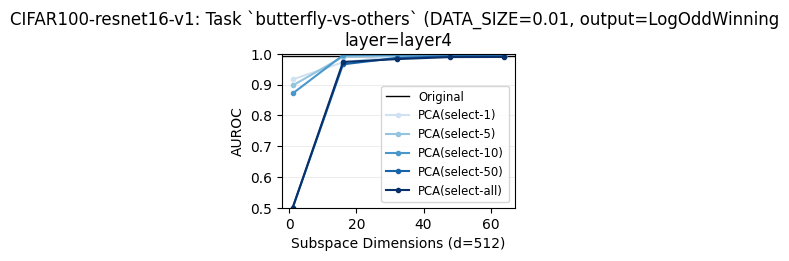

In [87]:
def viz(
    df, 
    basis_name,
    arr_selection_slugs=[
        'select-1', 
        'select-5', 
        'select-10', 
        'select-50', 
        'select-all'
    ],
    color_by_index=None,
):

    arr_layers = df.layer.unique()
    ncols = len(arr_layers)
    
    plt.figure(figsize=(3*ncols, 2))
    plt.suptitle(
        f"CIFAR100-resnet16-v1: Task `{SELECTED_GROUP}-vs-others` (DATA_SIZE={DATA_SIZE}, output=LogOddWinning", 
        y=1.1
    )
    cmap=mpl.colormaps["Blues"]


    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix+1)
        plt.ylim([0.5, 1])
        plt.title(f"layer={layer}")
        
        d = LAYER_DIM_MAPPING[layer]

        for six, slug in enumerate(arr_selection_slugs):
            
            _df = df[
                (df.basis_name == basis_name) \
                    & (df.sample_selection_criteria_slug == slug) \
                    & (df.layer==layer)
            ]
            criteria_name = _df.sample_selection_criteria.values[-1]
            
            assert _df.shape[0] > 0
            if six == 0:
                plt.axhline(ref_performance, label="Original", color="k", lw=1, ls="-")
                for v in [0.5, 0.6, 0.7, 0.8, 0.9]:
                    plt.axhline(v, lw=0.5, ls="-", alpha=0.1, color="k")
            # ls, color = ls_color_mapping(basis_name, pos_logit_only=pos_logit_only)
            if color_by_index is not None:
                color = color_by_index[six]
            else:
                color = cmap(six / len(arr_selection_slugs) + 0.2)
            
            plt.plot(
                _df.k,
                _df.val_auroc,
                marker=".",
                label=f"{basis_name}({slug})",
                color=color
            )

        if lix == 0:
            plt.ylabel("AUROC")
            plt.legend(fontsize="small")
        plt.xlabel(f"Subspace Dimensions (d={d})")
        
viz(
    df_stats_all,
    basis_name = "PCA",    
)

IndexError: index -1 is out of bounds for axis 0 with size 0

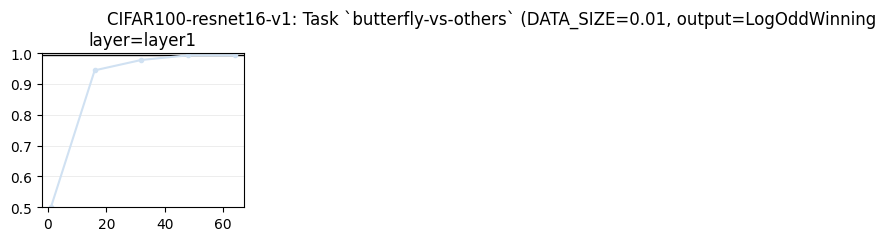

In [88]:
for basis_name in [
    "PCA", 
    "GradPCA", 
    "PRCAPosDef", "PRCASortAbs"
]:
    viz(
        df_stats,
        basis_name=basis_name,
    )
    plt.show()

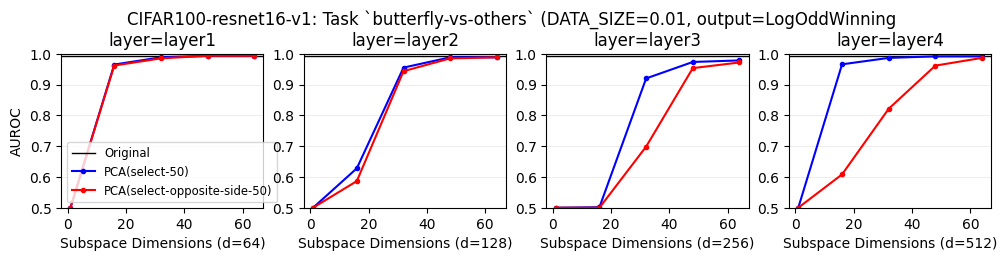

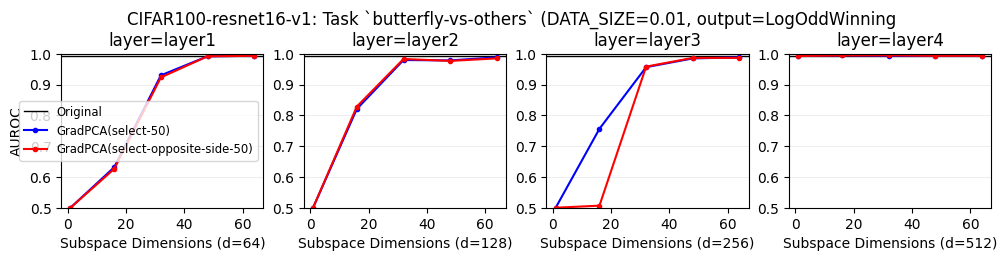

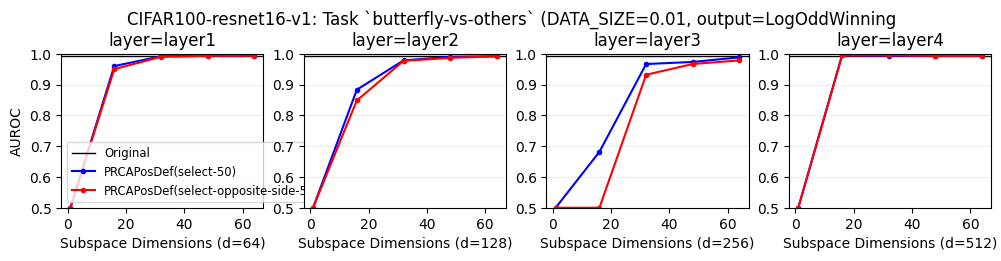

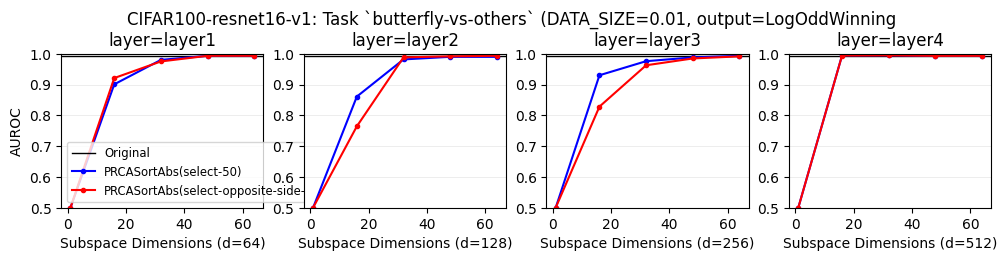

In [76]:
for basis_name in [
    "PCA", 
    "GradPCA", 
    "PRCAPosDef", "PRCASortAbs"
]:
    viz(
        df_stats,
        basis_name=basis_name,
        arr_selection_slugs=[
            'select-50', 
            'select-opposite-side-50',
        ],
        color_by_index=["blue", "red"]
    )
    plt.show()